In [ ]:
import pandas as pd


df = pd.read_csv(
    "../data/credit_card_approval.csv.zip",
    compression="zip",
)
df.columns = df.columns.str.lower()

df.shape

(9709, 20)

In [ ]:
# Tipos de las columnas

df.dtypes

id                   int64
gender               int64
own_car              int64
own_property         int64
work_phone           int64
phone                int64
email                int64
unemployed           int64
num_children         int64
num_family           int64
account_length       int64
total_income       float64
age                float64
years_employed     float64
income_type         object
education_type      object
family_status       object
housing_type        object
occupation_type     object
target               int64
dtype: object

<Axes: xlabel='email', ylabel='count'>

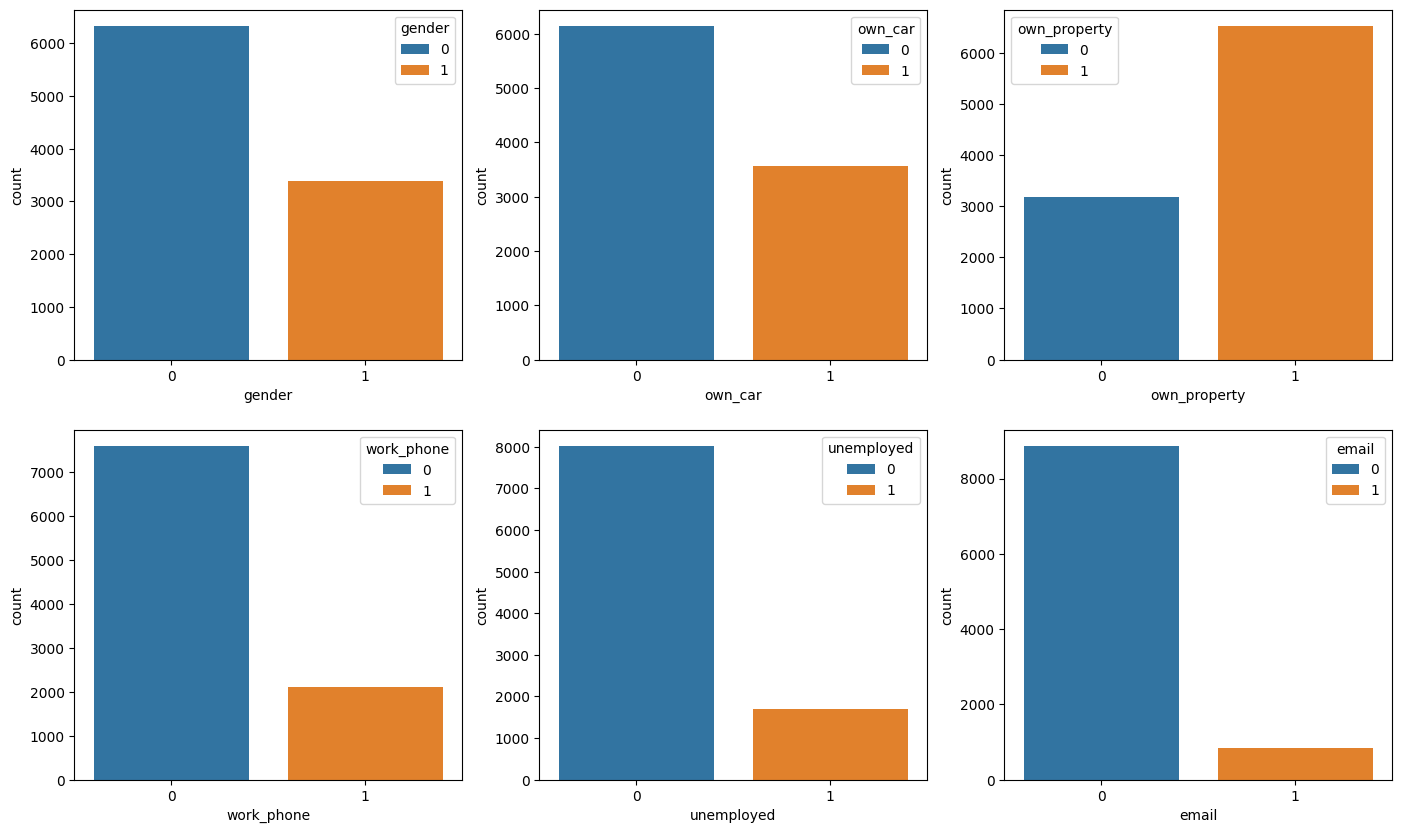

In [ ]:
# Características binarias
# Se verifica la distribucion de los valores para cada variable binaria

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 3, figsize=(17, 10))
sns.countplot(x=df["gender"], ax=ax[0, 0], hue=df["gender"])
sns.countplot(x=df["own_car"], ax=ax[0, 1], hue=df["own_car"])
sns.countplot(x=df["own_property"], ax=ax[0, 2], hue=df["own_property"])
sns.countplot(x=df["work_phone"], ax=ax[1, 0], hue=df["work_phone"])
sns.countplot(x=df["unemployed"], ax=ax[1, 1], hue=df["unemployed"])
sns.countplot(x=df["email"], ax=ax[1, 2], hue=df["email"])

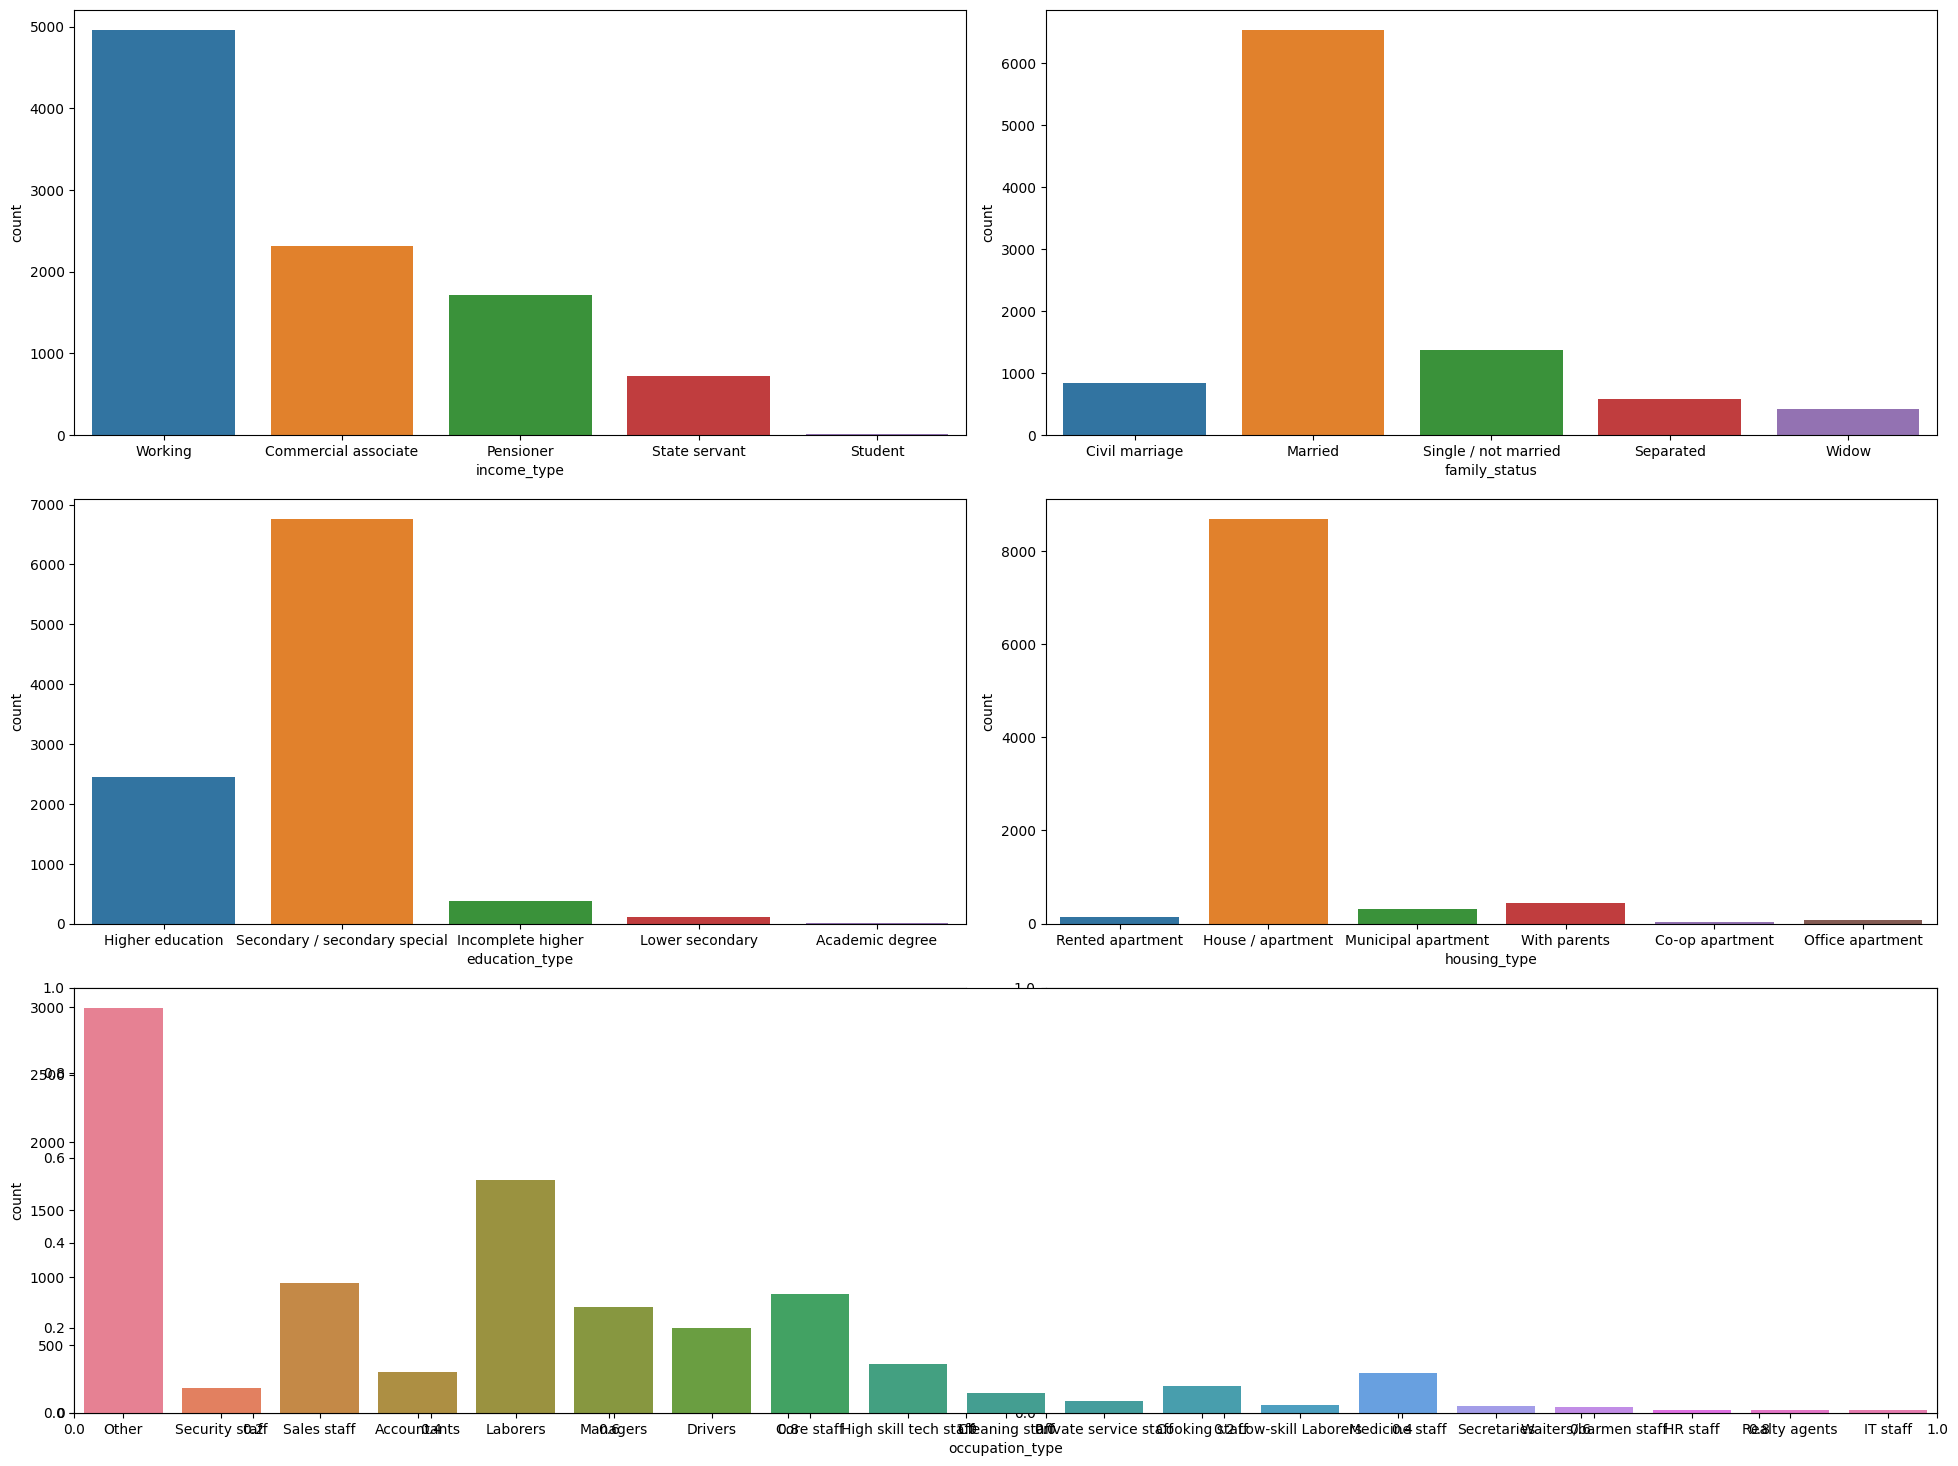

In [ ]:
# Caracteristicas categoricas
# La mayor parte de las personas estan trabajando, son casadas,
# viven en su propio apartamento/cada y tienen un nivel de educacion
# secundary/secundary special.

fig, ax = plt.subplots(3, 2, figsize=(20, 15))
sns.countplot(x=df["income_type"], ax=ax[0, 0], hue=df["income_type"])
sns.countplot(x=df["family_status"], ax=ax[0, 1], hue=df["family_status"])
sns.countplot(x=df["education_type"], ax=ax[1, 0], hue=df["education_type"])
sns.countplot(x=df["housing_type"], ax=ax[1, 1], hue=df["housing_type"])
ax_last = plt.subplot2grid((3, 2), (2, 0), colspan=2, fig=fig)
sns.countplot(x=df["occupation_type"], ax=ax_last, hue=df["occupation_type"])
plt.tight_layout()

<Axes: xlabel='account_length', ylabel='count'>

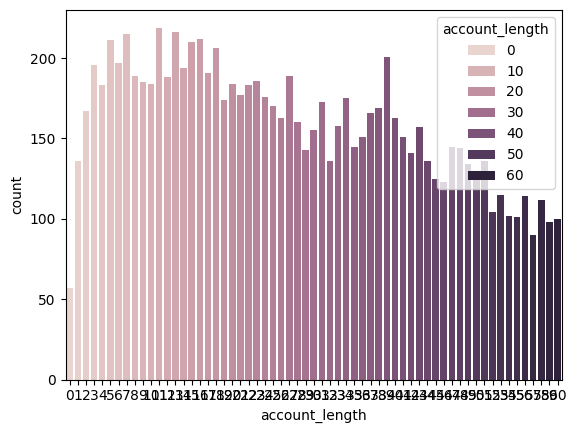

In [ ]:
# Caracteristicas numericas:
# Antiguedad de la cuenta en meses

sns.countplot(x=df["account_length"], hue=df["account_length"])

<Axes: xlabel='num_family', ylabel='count'>

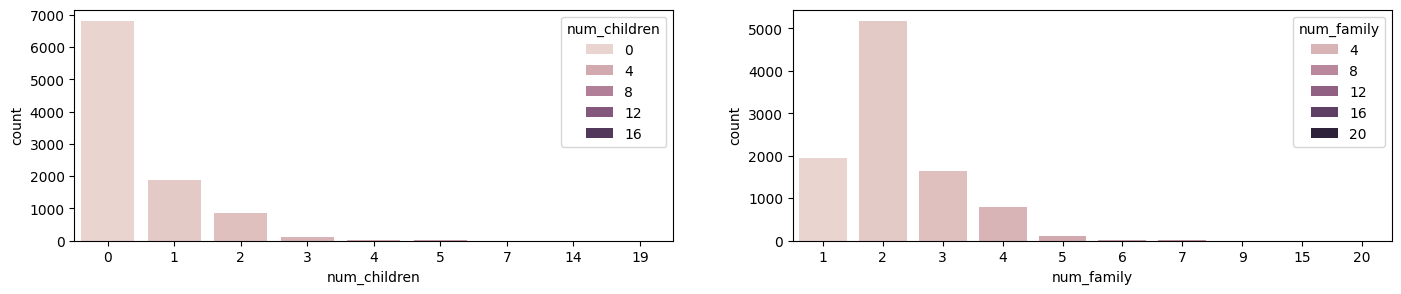

In [ ]:
# Numero de hijos y numero de miembros de la familia
# Las graficas muestran que hay outliers que difieren significativamente
# del resto de los datos. Se podrian considerar como errores de captura.

fig, ax = plt.subplots(1, 2, figsize=(17, 3))

sns.countplot(x=df["num_children"], ax=ax[0], hue=df["num_children"])
sns.countplot(x=df["num_family"], ax=ax[1], hue=df["num_family"])

<Axes: xlabel='id', ylabel='num_family'>

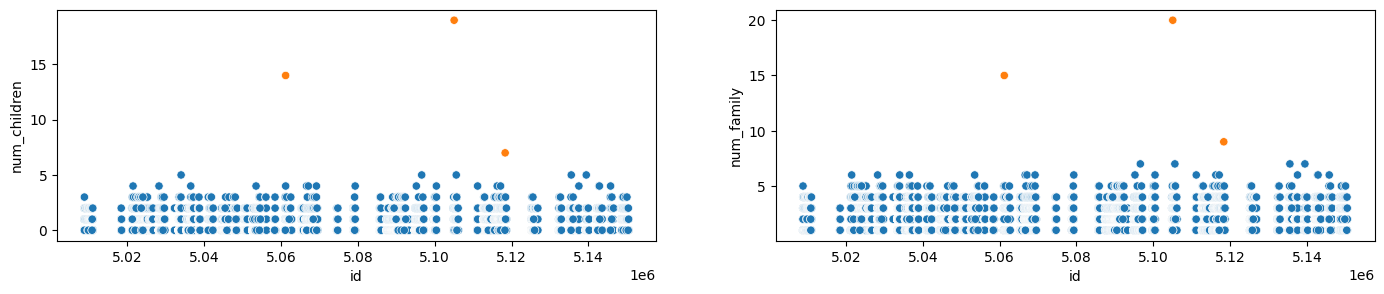

In [ ]:
# Visualizacion de los outliers en num_children y num_family

fig, ax = plt.subplots(1, 2, figsize=(17, 3))

ids = df["id"]

num_children = df["num_children"]
num_family = df["num_family"]

num_children_outliers = num_children > 5
num_family_outliers = num_family > 7

sns.scatterplot(
    x=ids, y=num_children, hue=num_children_outliers, legend=False, ax=ax[0]
)
sns.scatterplot(x=ids, y=num_family, hue=num_family_outliers, legend=False, ax=ax[1])

<Axes: xlabel='id', ylabel='num_family'>

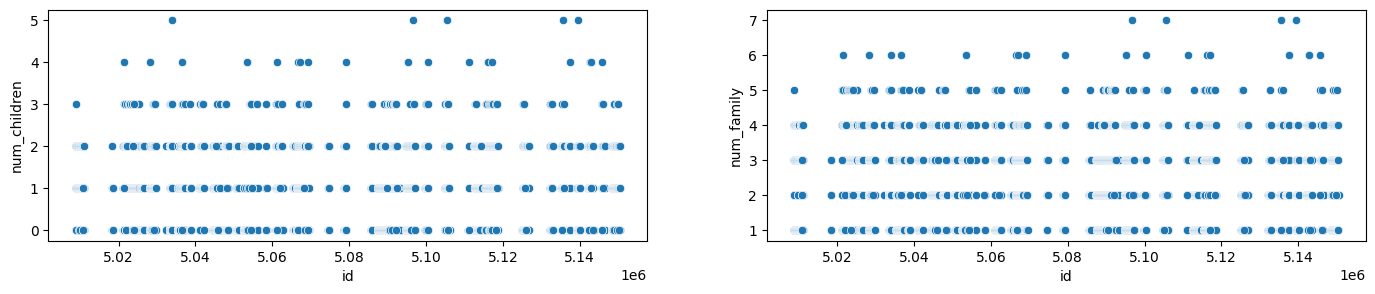

In [ ]:
# Numero de hijos y numero de miembros de la familia sin outliers

fig, ax = plt.subplots(1, 2, figsize=(17, 3))

ids = df["id"]

num_children = df["num_children"]
num_children = num_children[num_children <= 5]

num_family = df["num_family"]
num_family = num_family[num_family <= 7]

sns.scatterplot(x=ids, y=num_children, legend=False, ax=ax[0])
sns.scatterplot(x=ids, y=num_family, legend=False, ax=ax[1])

<Axes: xlabel='age'>

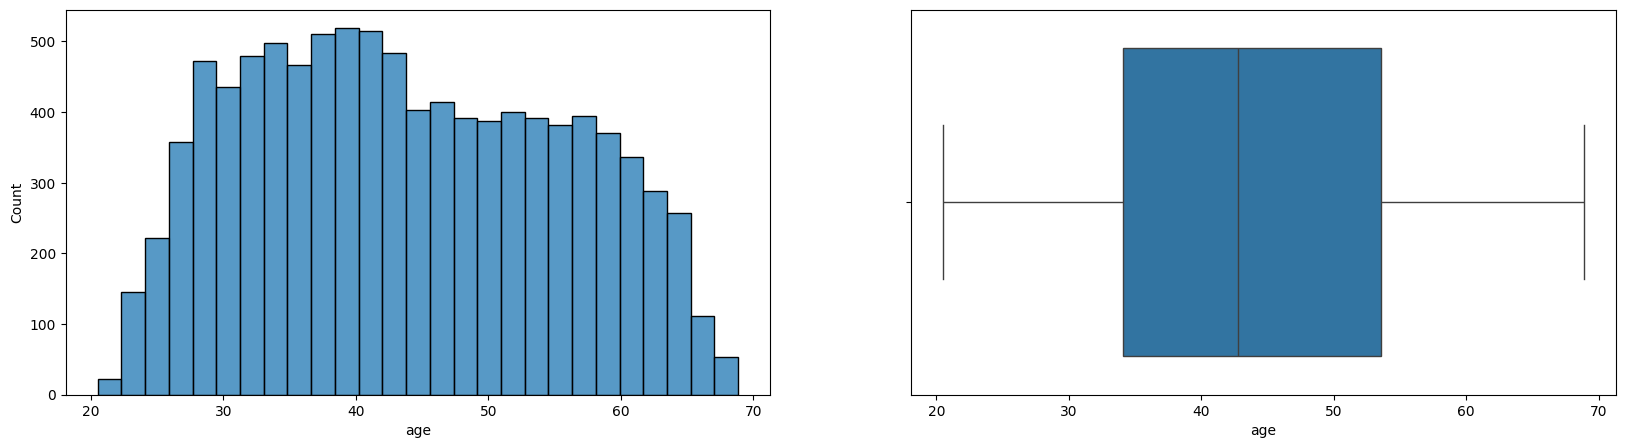

In [ ]:
# La columna age tiene una gran variabilidad y no hay valores
# que sean significativamente diferentes del resto.

fig, ax = plt.subplots(1, 2, figsize=(20, 5))

sns.histplot(x=df["age"], ax=ax[0])
sns.boxplot(x=df["age"], ax=ax[1])

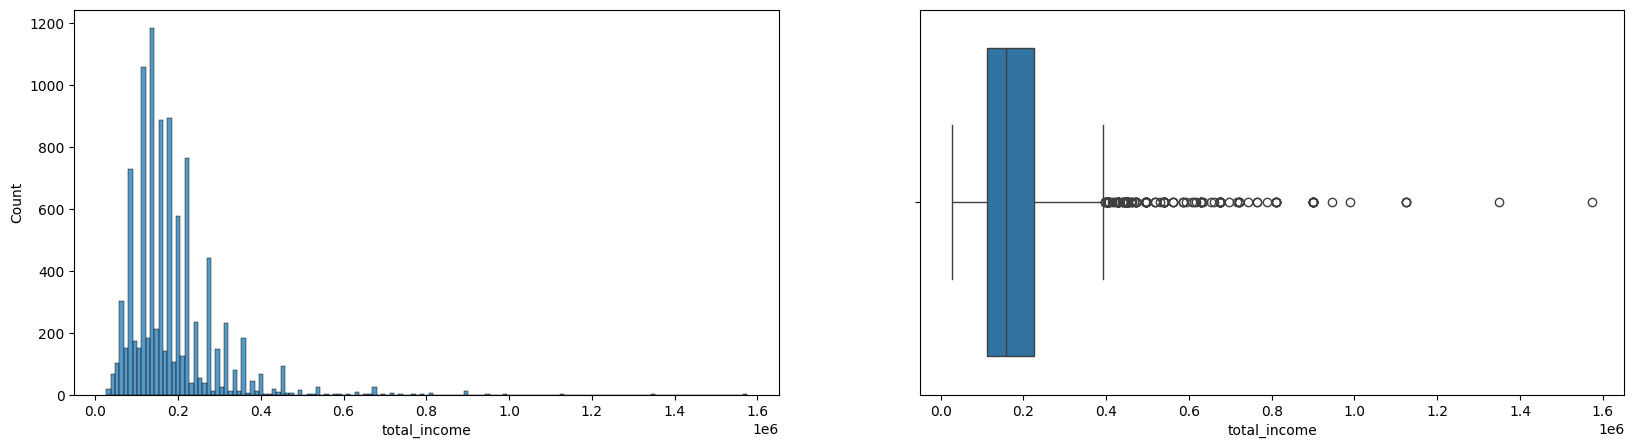

In [ ]:
# La distribución de total_income es asimétrica, con una fuerte concentración
# de los datos a la derecha y una gran cantidad de valores que pueden ser
# considerados como outliers.

fig, ax = plt.subplots(1, 2, figsize=(20, 5))

a = sns.histplot(x=df["total_income"], ax=ax[0])
b = sns.boxplot(x=df["total_income"], ax=ax[1])

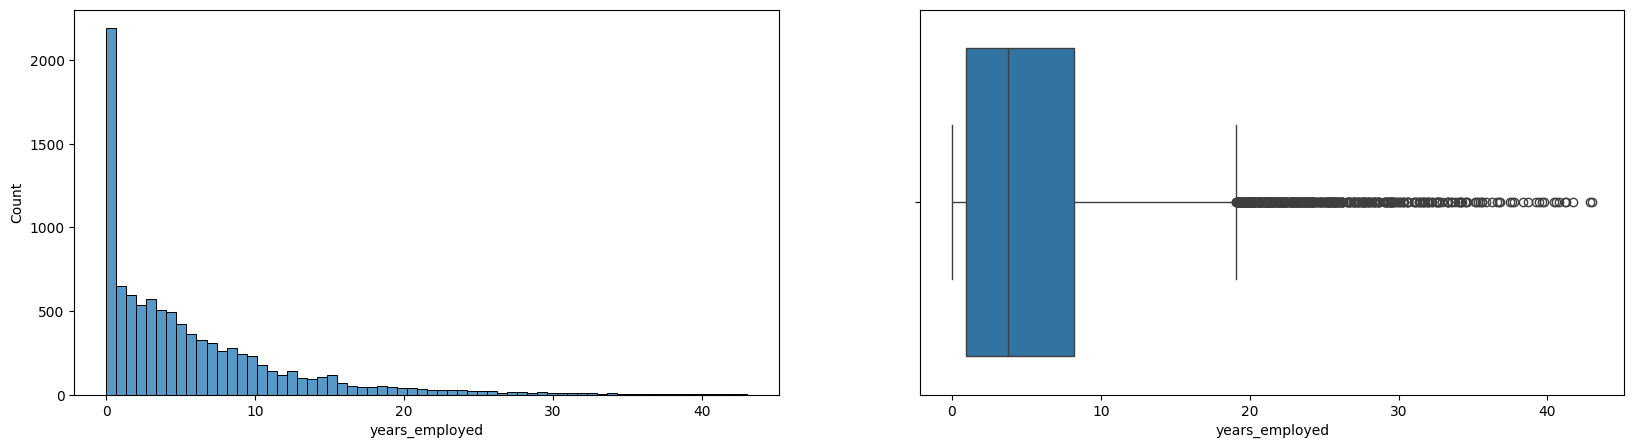

In [ ]:
# La distribución de years_employed es asimétrica, con una fuerte concentración
# de los datos a la derecha y una gran cantidad de valores que pueden ser
# considerados como outliers.

fig, ax = plt.subplots(1, 2, figsize=(20, 5))

a = sns.histplot(x=df["years_employed"], ax=ax[0])
b = sns.boxplot(x=df["years_employed"], ax=ax[1])

<Axes: xlabel='total_income'>

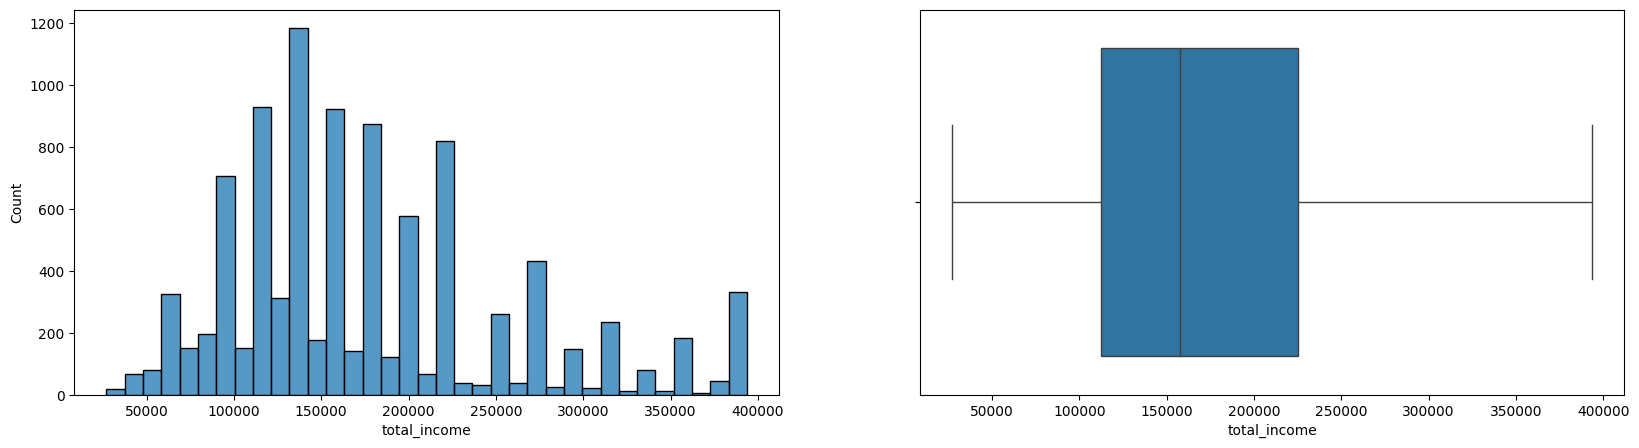

In [ ]:
# Una alternativa para manejo de un gran numero de outliers es limitar
# el range de los datos a un rango de valores que se consideren aceptables.
# En este ejemplo se utilizará el rango intercuartil.

total_income = df["total_income"]
first = total_income.quantile(0.25)
third = total_income.quantile(0.75)
iqr = third - first
upper_limit = third + 1.5 * iqr
lower_limit = first - 1.5 * iqr

# Se limitan los valores de total_income al rango intercuartil
total_income.mask(total_income > upper_limit, upper_limit, inplace=True)
total_income.mask(total_income < lower_limit, lower_limit, inplace=True)

fig, ax = plt.subplots(1, 2, figsize=(20, 5))
sns.histplot(x=total_income, ax=ax[0])
sns.boxplot(x=total_income, ax=ax[1])

<Axes: xlabel='years_employed'>

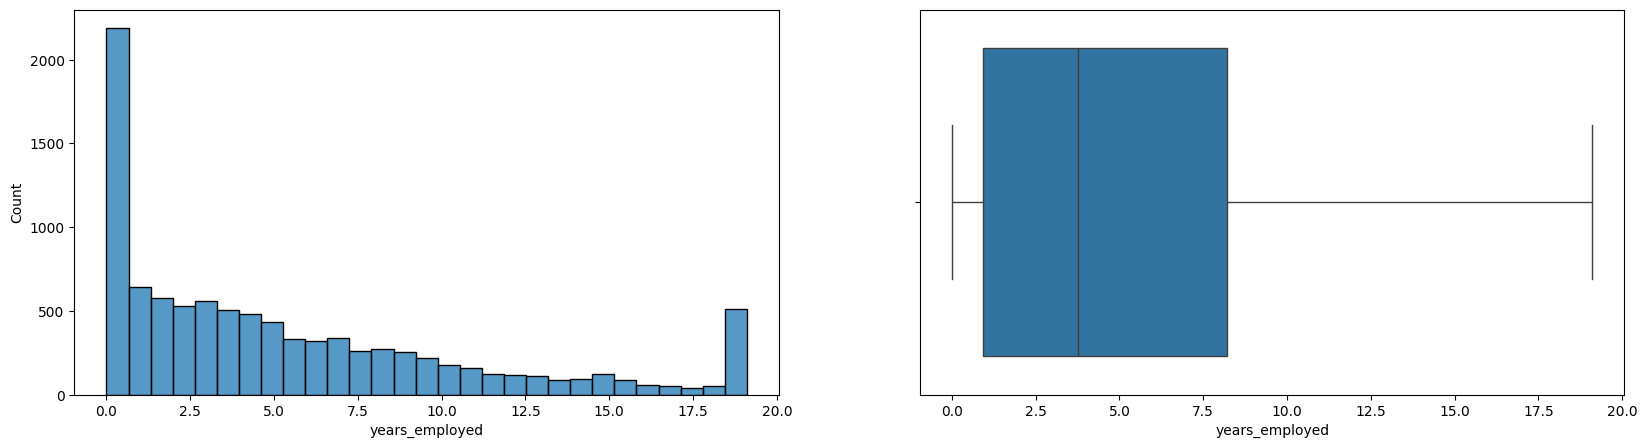

In [ ]:
# Se aplica la misma técnica para years_employed

years_employed = df["years_employed"]
first = years_employed.quantile(0.25)
third = years_employed.quantile(0.75)
iqr = third - first
upper_limit = third + 1.5 * iqr
lower_limit = first - 1.5 * iqr

years_employed.mask(years_employed > upper_limit, upper_limit, inplace=True)
years_employed.mask(years_employed < lower_limit, lower_limit, inplace=True)

fig, ax = plt.subplots(1, 2, figsize=(20, 5))
sns.histplot(x=years_employed, ax=ax[0])
sns.boxplot(x=years_employed, ax=ax[1])

In [ ]:
#
# Hace una copia para preservar la data original
#
"""

from nzpyida.ae import NZFunTApply

idadf = IdaDataFrame(idadb, 'CREDIT_CARD')

if (idadb.exists_table("credit_card_encoded")):
    idadb.drop_table("credit_card_encoded")

function_code = '''def apply_fun(self, df):
    from sklearn.preprocessing import LabelEncoder
    data = df.copy()


    #outliers handling

    data = data.loc[data['NUM_CHILDREN'] <= 5]
    data = data.loc[data['NUM_FAMILY'] <= 7]

    total_income = data['TOTAL_INCOME']
    first = total_income.quantile(0.25)
    third = total_income.quantile(0.75)
    iqr = third - first
    upper_limit = third + 1.5 * iqr
    lower_limit = first - 1.5 * iqr

    data['TOTAL_INCOME'].mask(data['TOTAL_INCOME'] > upper_limit, upper_limit, inplace=True)
    data['TOTAL_INCOME'].mask(data['TOTAL_INCOME'] < lower_limit, lower_limit, inplace=True)

    years_employed = data['YEARS_EMPLOYED']
    first = years_employed.quantile(0.25)
    third = years_employed.quantile(0.75)
    iqr = third - first
    upper_limit = third + 1.5 * iqr
    lower_limit = first - 1.5 * iqr

    data['YEARS_EMPLOYED'].mask(data['YEARS_EMPLOYED'] > upper_limit, upper_limit, inplace=True)
    data['YEARS_EMPLOYED'].mask(data['YEARS_EMPLOYED'] < lower_limit, lower_limit, inplace=True)


    #encoding
    for column in data.columns:
        if data[column].dtype=='object':
            le = LabelEncoder()
            le.fit(list(data[column].values))
            data[column] = le.transform(data[column].values)

                def print_output(x):
        row = [x['ID'], x['INCOME_TYPE'], x['EDUCATION_TYPE'], x['FAMILY_STATUS'], x['HOUSING_TYPE'], x['OCCUPATION_TYPE']]
        self.output(row)

    data.apply(print_output, axis=1)
'''

output_signature = {'ID': 'double', 'INCOME_TYPE_ENC': 'float', 'EDUCATION_TYPE_ENC': 'float', 'FAMILY_STATUS_ENC': 'float', 'HOUSING_TYPE_ENC': 'float', 'OCCUPATION_TYPE_ENC': 'float'}

nz_apply = NZFunTApply(df=idadf, code_str=function_code, fun_name='apply_fun', parallel=False, output_table="credit_card_encoded",output_signature=output_signature, merge_output_with_df=True)
idadf = nz_apply.get_result()
"""
data = df.copy()

data = data[
    [
        "id",
        "gender",
        "own_car",
        "own_property",
        "work_phone",
        "phone",
        "email",
        "unemployed",
        "num_children",
        "num_family",
        "account_length",
        "total_income",
        "age",
        "years_employed",
        "income_type",
        "education_type",
        "family_status",
        "housing_type",
        "occupation_type",
        "target",
    ]
]


# Outliers en num_children

data = data.loc[data["num_children"] <= 5]


# Outliers en num_family

data = data.loc[data["num_family"] <= 7]


# Outliers en total_income

total_income = data["total_income"]
first = total_income.quantile(0.25)
third = total_income.quantile(0.75)
iqr = third - first
upper_limit = third + 1.5 * iqr
lower_limit = first - 1.5 * iqr
data["total_income"].mask(data["total_income"] > upper_limit, upper_limit, inplace=True)
data["total_income"].mask(data["total_income"] < lower_limit, lower_limit, inplace=True)


# Outliers en years_employed

years_employed = data["years_employed"]
first = years_employed.quantile(0.25)
third = years_employed.quantile(0.75)
iqr = third - first
upper_limit = third + 1.5 * iqr
lower_limit = first - 1.5 * iqr
data["years_employed"].mask(
    data["years_employed"] > upper_limit, upper_limit, inplace=True
)
data["years_employed"].mask(
    data["years_employed"] < lower_limit, lower_limit, inplace=True
)

In [ ]:
# Conjuntos de entrenamiento y prueba

from sklearn.model_selection import train_test_split  #  type: ignore

X = data.drop(columns=["target", "id"])
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

KeyError: "['target'] not found in axis"

In [ ]:
# Construccion del modelo

from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

model = Pipeline(
    [
        (
            "transformer",
            ColumnTransformer(
                [
                    (
                        "encoder",
                        OrdinalEncoder(),
                        make_column_selector(dtype_include=object),
                    ),
                ],
                remainder="passthrough",
            ),
        ),
        (
            "rf",
            RandomForestClassifier(n_estimators=1, max_depth=28, min_samples_leaf=7),
        ),
    ]
)


model.fit(X_train, y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder', OrdinalEncoder(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x12594c790>)])),
                ('rf',
                 RandomForestClassifier(max_depth=28, min_samples_leaf=7,
                                        n_estimators=1))])

In [17]:
y_train_predict = model.predict(X_train)
y_test_predict = model.predict(X_test)
print("Train Accuracy Score: {:.5}".format(accuracy_score(y_train, y_train_predict)))
print(" Test Accuracy Score: {:.5}".format(accuracy_score(y_test, y_test_predict)))

Train Accuracy Score: 0.85531
 Test Accuracy Score: 0.82589


In [18]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.model_selection import StratifiedKFold

# param_grid = [
#     {
#         "rf__n_estimators": list(range(1, 50, 1)),
#         "rf__max_depth": list(range(1, 30, 1)),
#         "rf__min_samples_leaf": list(range(5, 40, 1)),
#     },
# ]

# gridSearchCV = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     cv=StratifiedKFold(10),
#     scoring="balanced_accuracy",
#     n_jobs=-1,
# )

# gridSearchCV.fit(X_train, y_train)
# gridSearchCV.best_estimator_

In [ ]:
# Matriz de confusion para el conjunto de entrenamiento

from sklearn.metrics import confusion_matrix


pd.DataFrame(
    data=confusion_matrix(y_train, model.predict(X_train)),
    index=["True 0", "True 1"],
    columns=["Predicted 0", "Predicted 1"],
)

,Predicted 0,Predicted 1
True 0,5658,239
True 1,744,153


In [20]:
#
# Matriz de confusion para el conjunto de testing
#
pd.DataFrame(
    data=confusion_matrix(y_test, model.predict(X_test)),
    index=["True 0", "True 1"],
    columns=["Predicted 0", "Predicted 1"],
)

,Predicted 0,Predicted 1
True 0,2378,149
True 1,358,27


Text(0, 0.5, 'Mean decrease in impurity')

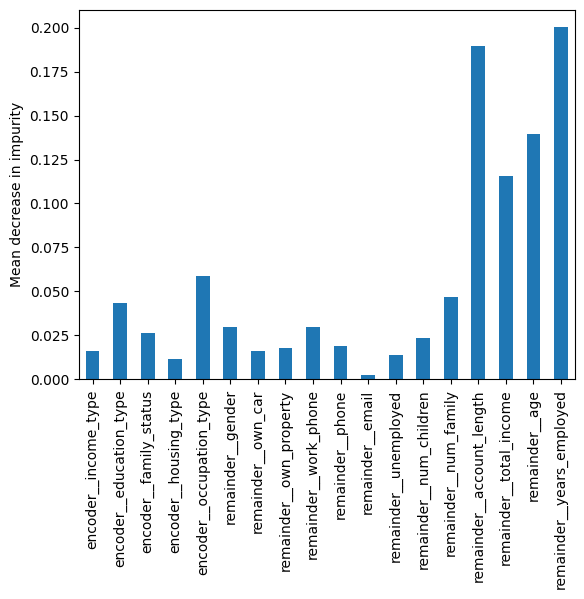

In [ ]:
# Analisis de los resultados

importances = model.named_steps["rf"].feature_importances_
feature_names = model.named_steps["transformer"].get_feature_names_out()

std = np.std(
    [tree.feature_importances_ for tree in model.named_steps["rf"].estimators_], axis=0
)


forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_ylabel("Mean decrease in impurity")

([<matplotlib.patches.Wedge at 0x1284e39d0>,
 [Text(-0.20761142565443555, -1.080230297639227, 'Rejected'),
  Text(0.20761107367071618, 1.080230365287559, 'Approved')],
 [Text(-0.11324259581151029, -0.5892165259850328, '94.0%'),
  Text(0.11324240382039064, 0.5892165628841229, '6.0%')])

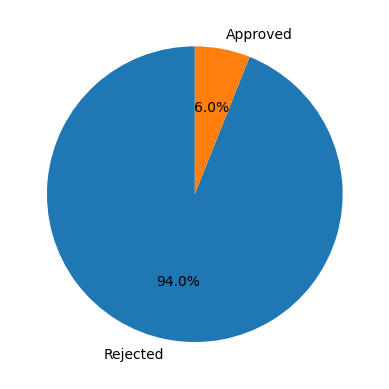

In [22]:
# construye un grafico de torta con el total de aprobados y rechazados

rejected = model.predict(X_test) == 0
approved = model.predict(X_test) == 1

fig, ax = plt.subplots()
ax.pie(
    [rejected.sum(), approved.sum()],
    labels=["Rejected", "Approved"],
    autopct="%1.1f%%",
    startangle=90,
)

[Text(0.5, 1.0, 'REJECTED')]

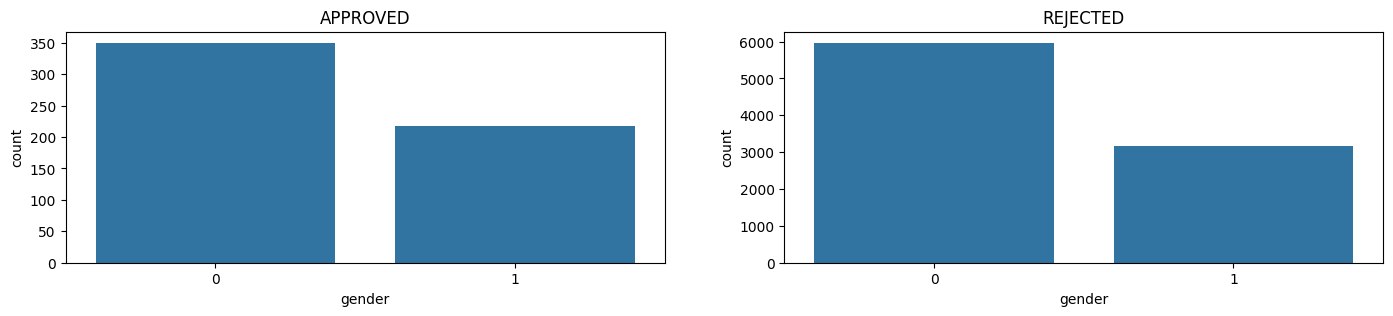

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(17, 3))

df_approved = X.loc[model.predict(X) == 1, "gender"]
sns.countplot(
    x=df_approved,
    ax=ax[0],
).set(title="APPROVED")

df_rejected = X.loc[model.predict(X) == 0, "gender"]
sns.countplot(
    x=df_rejected,
    ax=ax[1],
).set(title="REJECTED")

# Por qué esta mal esta aproximación?